In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from rounding import round_unc

# Problem 7.2


In [207]:
mass = np.array([1967.0, 1969.0, 1972.1])  # MeV / c^2
mass_err = np.array([1.0, 1.4, 2.5])  # MeV / c^2
weights = mass_err**-2  # (1/(MeV/c^2)^2)
best_est = np.sum(weights * mass) / np.sum(weights)
best_err = 1 / np.sqrt(np.sum(weights))
best_est, best_err = round_unc(best_est, best_err)
print(f"Best estimate: ({best_est} ± {best_err}) MeV/c^2")

Best estimate: (1968.1 ± 0.8) MeV/c^2


# Problem 7.4


In [208]:
wavelength = np.array([503, 491, 525, 570]).astype(float)  # nm
wavelength_err = np.array([10, 8, 20, 40]).astype(float)  # nm
weights = wavelength_err**-2  # (1/(nm)^2)
best_est = np.sum(weights * wavelength) / np.sum(weights)
best_err = 1 / np.sqrt(np.sum(weights))
best_est, best_err = round_unc(best_est, best_err)
print(f"Best estimate: ({best_est} ± {best_err}) nm")
print("Weights: ", weights)

Best estimate: (500.0 ± 6.0) nm
Weights:  [0.01     0.015625 0.0025   0.000625]


One could make the argument that the final measurement is not worth including because its weight is several orders of magnitude smaller than the largest contribution (0.000625 vs. 0.01).


# Problem 7.6


In [209]:
counts = np.array([412, 576])  # unitless
times = np.array([4, 6])  # hours
counts_err = np.sqrt(counts)  # unitless
rates = counts / times  # 1/hours

Using the previous uncertainty estimation rules:


In [210]:
rates_err = rates * np.sqrt((counts_err / counts) ** 2)
rates1, rates1_err = round_unc(rates, rates_err)
for i in range(len(rates)):
    print(f"Rate {i + 1}: ({rates1[i]} ± {rates1_err[i]}) 1/hours")

Rate 1: (103.0 ± 5.0) 1/hours
Rate 2: (96.0 ± 4.0) 1/hours


Using a weighted average:


In [211]:
weights = counts_err**-2
best_est = np.sum(weights * rates) / np.sum(weights)
best_err = 1 / np.sqrt(np.sum(weights))
best_est, best_err = round_unc(best_est, best_err)
print(f"Weighted average: ({best_est} ± {best_err}) 1/hours")

Weighted average: (100.0 ± 15.0) 1/hours


# Problem 8.1


In [223]:
x = np.array([1, 3, 5])
y = np.array([6, 5, 1])

ones_vect = np.ones(len(x))
A = np.column_stack((x, ones_vect))
A_T = A.T
gram = A_T @ A
gram_inv = np.linalg.inv(gram)
A_T_y = A_T @ y
x_best = gram_inv @ A_T_y
slope, intercept = x_best[0], x_best[1]


In [234]:
A, B = intercept, slope
y_hat = A + B * x
deviations = y - y_hat
coeff = 1 / (len(x) - 2)
y_err = np.sqrt(coeff * np.sum(deviations**2))
delta = len(x) * np.sum(x**2) - np.sum(x) ** 2

A_err = y_err * np.sqrt(np.sum(x**2) / delta)
B_err = y_err * np.sqrt(len(x) / delta)

A_reported, A_err_reported = round_unc(A, A_err)
B_reported, B_err_reported = round_unc(B, B_err)

print(f"y_err: {y_err.round(1)}")
print(f"A: {A_reported} ± {A_err_reported}")
print(f"B: {B_reported} ± {B_err_reported}")

y_err: 1.2
A: 7.7 ± 1.5
B: -1.2 ± 0.4


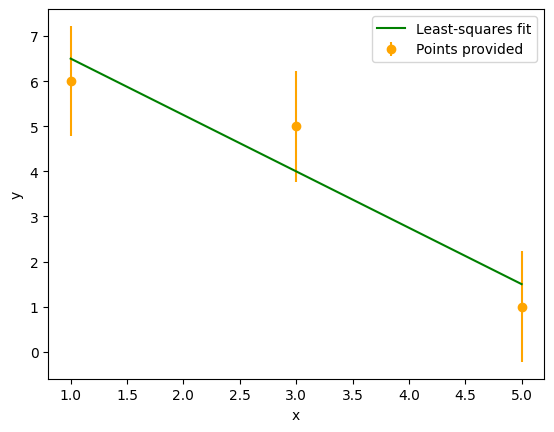

In [214]:
plt.errorbar(x, y, yerr=y_err, label="Points provided", color="orange", fmt="o")
plt.plot(x, slope * x + intercept, label="Least-squares fit", color="green")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Problem 8.7


In [215]:
x = np.array([200, 300, 400, 500, 600, 700, 800, 900])  # g
y = np.array([5.1, 5.5, 5.9, 6.8, 7.4, 7.5, 8.6, 9.4])  # cm

In [216]:
ones = np.ones(len(x))
A = np.column_stack((x, ones))
A_T = A.T
gram = A_T @ A
gram_inv = np.linalg.inv(gram)
A_T_y = A_T @ y
x_best = gram_inv @ A_T_y
slope, intercept = x_best[0], x_best[1]
A, B = intercept, slope

coeff = 1 / (len(x) - 2)
y_hat = slope * x + intercept
deviations = y - y_hat
y_err = np.sqrt(coeff * np.sum(deviations**2))
delta = len(x) * np.sum(x**2) - np.sum(x) ** 2

A_err = y_err * np.sqrt(np.sum(x**2) / delta)
B_err = y_err * np.sqrt(len(x) / delta)

A_reported, A_err_reported = round_unc(A, A_err)
B_reported, B_err_reported = round_unc(B, B_err)

print(f"A: ({A_reported} ± {A_err_reported}) cm")
print(f"B: ({B_reported} ± {B_err_reported}) cm/g")

A: (3.69 ± 0.22) cm
B: (0.0061 ± 0.0004) cm/g


Let $s$ represent the slope resulting from least squares fitting.

$$
s = \frac{g}{k} \Rightarrow k = \frac{g}{s}
$$

Thus

$$
\delta k = k \cdot \sqrt{
    \left ( \frac{\delta s}{s} \right ) ^ 2
}
$$


In [ ]:
def compute_delta_k(s, deltas, k):
    return k * np.sqrt(np.sum(deltas / s) ** 2)


def compute_k(s):
    g = 9.81 * 100  # cm/s^2
    return g / s


k = compute_k(slope)
delta_k = compute_delta_k(slope, B_err, k)
k_reported, delta_k_reported = round_unc(k, delta_k)

print(f"k: ({k_reported} ± {delta_k_reported}) g / s^2")
print(f"l_0: ({A_reported} ± {A_err_reported}) cm")

k: (160000.0 ± 10000.0) cm/g
l_0: (3.69 ± 0.22) cm


# Problem 8.8


\begin{align}
v\_{\text{avg}} &= \frac{1}{4}\left(\frac{s_2 - s_1}{\Delta t} + \frac{s_3 - s_2}{\Delta t} + \frac{s_4 - s_3}{\Delta t} + \frac{s_5 - s_4}{\Delta t}\right) \\
&= \frac{1}{4\Delta t}(s_2 - s_1 + s_3 - s_2 + s_4 - s_3 + s_5 - s_4) \\
&= \frac{1}{4\Delta t}(s_5 - s_1) \\
&= \frac{s_5 - s_1}{4\Delta t} \\
&= \frac{1}{4} \cdot \frac{s_5 - s_1}{t_5 - t_1}
\end{align}


In [218]:
test_x = np.array([-4, -2, 0, 2, 4])
test_y = np.array([13, 25, 34, 42, 56])
delta_t = 2
v_avg_expanded = (
    (test_y[1] - test_y[0])
    + (test_y[2] - test_y[1])
    + (test_y[3] - test_y[2])
    + (test_y[4] - test_y[3])
) / (4 * delta_t)

v_avg_direct = (test_y[4] - test_y[0]) / (4 * delta_t)
print(f"v_avg_expanded: {v_avg_expanded}")
print(f"v_avg_direct: {v_avg_direct}")

v_avg_expanded: 5.375
v_avg_direct: 5.375


Both methods produce the same answer, ignoring the middle three points.


In [219]:
def least_squares_regression(x, y):
    # Find the design matrix, then the Moore-Penrose pseudoinverse
    # applied to y to approximately solve A x = y
    ones = np.ones(len(x))
    A = np.column_stack((x, ones))
    A_T = A.T
    gram = A_T @ A
    gram_inv = np.linalg.inv(gram)
    A_T_y = A_T @ y
    x_best = gram_inv @ A_T_y
    slope, intercept = x_best[0], x_best[1]

    # Estimate y-uncertainties and compute the error in the fit
    y_hat = slope * x + intercept
    deviations = y - y_hat
    coeff = 1 / (len(x) - 2)
    y_err = np.sqrt(coeff * np.sum(deviations**2))
    delta = len(x) * np.sum(x**2) - np.sum(x) ** 2
    intercept_err = y_err * np.sqrt(np.sum(x**2) / delta)
    slope_err = y_err * np.sqrt(len(x) / delta)

    return slope, intercept, slope_err, intercept_err

In [220]:
v, s0, v_err, s0_err = least_squares_regression(test_x, test_y)
v, v_err = round_unc(v, v_err)
s0, s0_err = round_unc(s0, s0_err)

print(f"v: {v} ± {v_err}")
print(f"s0: {s0} ± {s0_err}")

v: 5.15 ± 0.28
s0: 34.0 ± 0.8


The direct-averaging method yields an estimate of 5.375, while least squares produces 5.15. These are reasonably close--within 1 $\sigma$, defining $\sigma$ as the uncertainty in $v$ derived from least squares regression.


# Problem 8.14


See the previous solution for a best estimate for $v$.


# Problem 8.15


Applying the least squares routine from problem 8.8:


In [221]:
x = np.array(range(1, 7))  # unitless
y = np.array([5.0, 14.4, 23.1, 32.3, 41.0, 50.4])  # cm

In [222]:
B, A, B_err, A_err = least_squares_regression(x, y)
wavelen = 2 * B
wavelen_err = 2 * B_err
wavelen, wavelen_err = round_unc(wavelen, wavelen_err)
print(f"Wavelength: ({wavelen} ± {wavelen_err}) cm")


Wavelength: (18.1 ± 0.1) cm
